In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
df= pd.read_csv("weatherAUS.csv")
df.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
df = df.drop(['Date'], axis=1)
df.head(5)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
df['Sunshine'].value_counts()

Sunshine
0.0     2359
10.7    1101
11.0    1094
10.8    1069
10.5    1027
        ... 
14.0      15
14.1       6
14.3       4
14.2       2
14.5       1
Name: count, Length: 145, dtype: int64

In [5]:
imputer = SimpleImputer(strategy='median')
num_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed','Sunshine', 'Evaporation','WindSpeed9am','WindSpeed3pm','Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Cloud9am','Cloud3pm', 'Temp9am','Temp3pm' ]
df[num_cols] = imputer.fit_transform(df[num_cols])

In [6]:
Rain = {'Yes' : 1, 'No' : 0}
df['RainToday']    = df['RainToday'].map(Rain)
df['RainTomorrow'] = df['RainTomorrow'].map(Rain)
df.head(5)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,0.0,0.0
1,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,0.0,0.0
2,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,0.0,0.0
3,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,0.0,0.0
4,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0.0,0.0


In [7]:
encoder = OneHotEncoder(sparse_output=False)
cat_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location']
matrix = encoder.fit_transform(df[cat_cols])
column_names = encoder.get_feature_names_out(cat_cols)
for i in range(len(matrix.T)):
    df[column_names[i]] = matrix.T[i]
df = df.drop(cat_cols, axis=1)
df = df.dropna(subset=['RainToday', 'RainTomorrow'])

/var/folders/pl/tscqj2xn6n97b5f7tpg8j_100000gn/T/ipykernel_20169/3478195172.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[column_names[i]] = matrix.T[i]


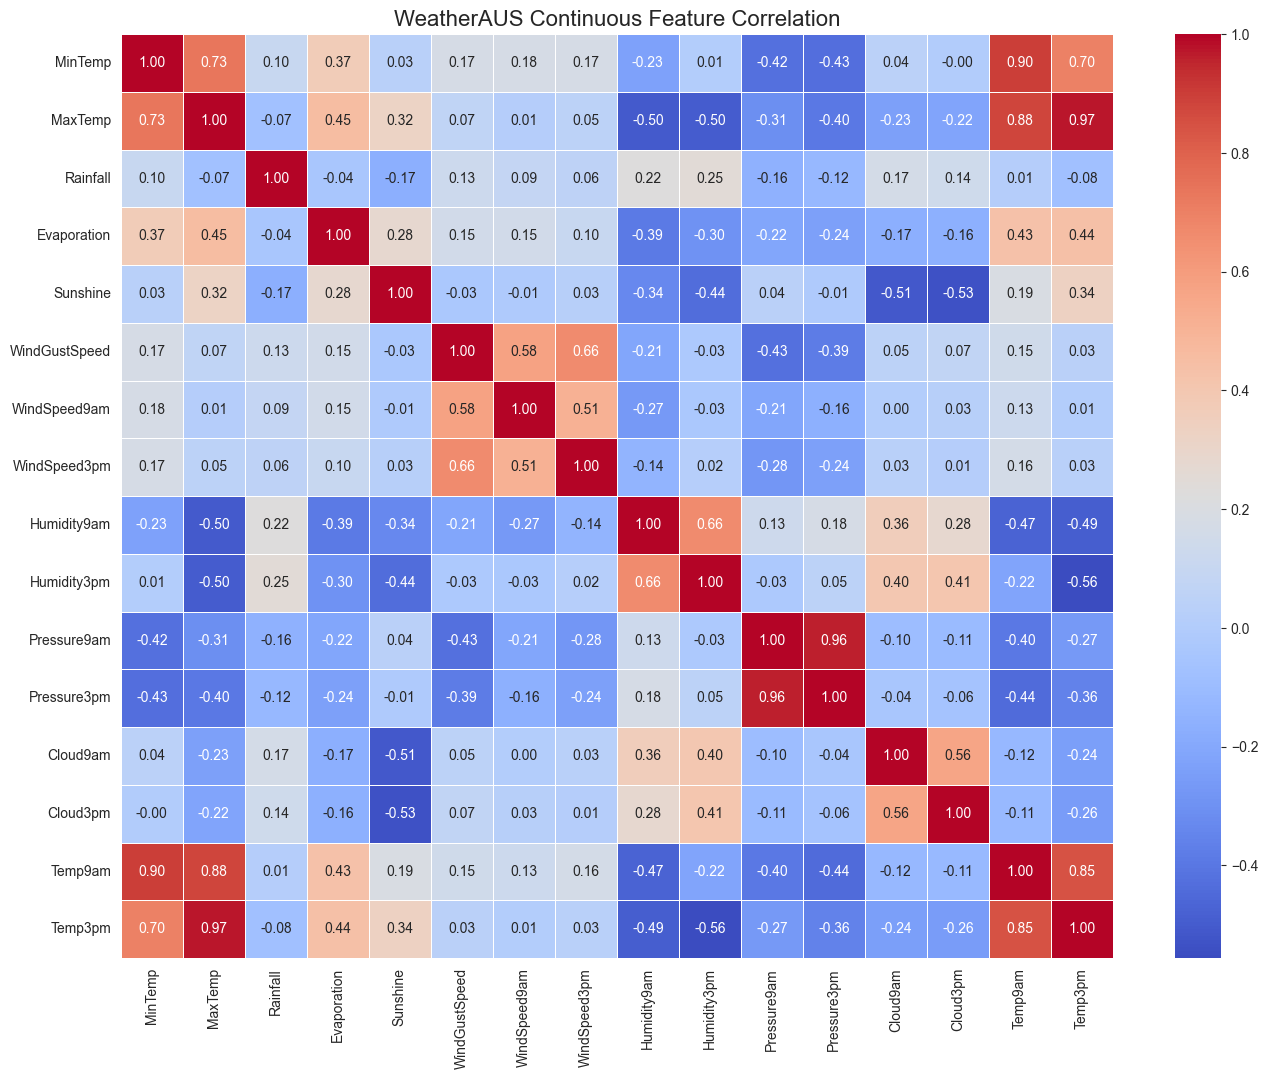

In [8]:
base_nums = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
             'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
             'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
             'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

corr_matrix = df[base_nums].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('WeatherAUS Continuous Feature Correlation', fontsize=16)
plt.show()

In [9]:
drop_cols = ['Temp3am', 'Pressure9am', 'Temp9am', 'Evaporation', 'Cloud9am','Humidity9am']
df = df.drop(drop_cols, axis=1)

In [10]:
def cap_outliers(series, mult=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (mult * iqr)
    upper = q3 + (mult * iqr)

    return series.clip(lower=lower, upper=upper)

outlier_cols = ['Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']

for col in outlier_cols:
    df[col] = cap_outliers(df[col], mult=1.5)

In [11]:
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


In [13]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def gradient(theta, X, y, class_weight=None):
    m = y.size
    errors = sigmoid(X @ theta) - y
    if class_weight is not None:
        weights = np.where(y == 1, class_weight[1], class_weight[0])
        errors = errors * weights
    return X.T @ (errors / m)

def gradient_descent(X, y, alpha=0.1, epochs=5000, class_weight=None, tol=1e-5):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    theta = np.zeros(X_b.shape[1])
    for i in range(epochs):
        grad = gradient(theta, X_b, y, class_weight=class_weight)
        theta -= alpha * grad
        if np.linalg.norm(grad) < tol:
            break
    return theta

def probablity(X, theta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return sigmoid(X_b @ theta)

def prediction(X, theta, threshold = 0.695):
    return (probablity(X, theta) >= threshold).astype(int)

In [14]:
w0 = len(y_train) / (2 * (y_train == 0).sum())
w1 = len(y_train) / (2 * (y_train == 1).sum())
theta_hat = gradient_descent(X_train_sm, y_train_sm.to_numpy(), alpha=0.1, epochs=5000, class_weight=None)

y_train_pred = prediction(X_train, theta_hat, threshold=0.695)
y_test_pred  = prediction(X_test,  theta_hat, threshold=0.695)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")

Train accuracy: 0.8386
Test accuracy:  0.8357


In [15]:
print(y_train_pred.sum())

9965


In [16]:
## smote
## outliers
## corellation

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

pr = precision_score(y_test, y_test_pred)
rc = recall_score(y_test, y_test_pred)
f = f1_score(y_test, y_test_pred, average='weighted')
fa = f1_score(y_test, y_test_pred)

print(f"Precision: {pr:.4f}")
print(f"Recall: {rc:.4f}")
print(f"F1 Score(Weighted): {f:.4f}")
print(f"F1 Score: {fa:.4f}")

Precision: 0.8355
Recall: 0.3253
F1 Score(Weighted): 0.8062
F1 Score: 0.4683
